# BERT Reranker, example mixed-length workload: trn2.3xlarge, native, LNC=2

[Alibaba-NLP/gte-multilingual-reranker-base](https://huggingface.co/Alibaba-NLP/gte-multilingual-reranker-base)
behind NVIDIA Triton Inference Server, benchmarked with an **example mixed-length workload**
rather than a fixed sequence length.

**Path**: PyTorch Native, `torch.compile(backend="neuron")` | **dtype**: full BF16 | **Triton model instances**: 4 (one per NeuronCore, each holding every length)

**GELU**: this notebook swaps the model's exact (erf) GELU for `nn.GELU(approximate="tanh")`.
On the PyTorch Native path exact GELU is lowered through FP32 and, on trn2 at seq=256 x 32, costs
about 36 ms of a 99 ms call; tanh GELU stays in BF16 and the call drops to 63 ms (+57%). On CPU in
FP32 the two GELUs give cosine 0.999995-0.999997 over 64 query/passage pairs at lengths 128-512, the
same top-1 for every query, and Spearman >= 0.997. The trace path is the same speed with either
GELU, so the trace notebooks keep the exact GELU.

## The example workload

An illustrative workload, in round numbers, shaped like a typical search reranker: mostly short
query+passage pairs sent in large batches. Five length buckets; the client groups each request's
sequences by length and sends one Triton call per bucket, up to 32 sequences per call.

| bucket | % Triton calls | mean sequences per call | % sequences (derived) | % compute (derived) |
|---:|---:|---:|---:|---:|
| 128 | 30 | 6 | 10.9 | 5.5 |
| 256 | 50 | 28 | 84.8 | 85.2 |
| 512 | 15 | 4 | 3.6 | 7.3 |
| 768 | 3 | 2 | 0.4 | 1.1 |
| 1024 | 2 | 2 | 0.2 | 1.0 |

Call sizes are drawn per bucket from a distribution with that mean. **To model your own traffic,
edit `EXAMPLE_MIX` in Step 5** and re-run; the bucket sets in Step 1 may then also need revisiting.

## What gets compiled

Sparse batch buckets per length, chosen from the call-size distribution. A call is routed to the
smallest compiled batch that fits it.

| length | PyTorch Native (24 graphs) | trace (12 graphs) |
|---:|---|---|
| 128 | 1, 4, 8, 16, 32 | 8, 32 |
| 256 | 8, 16, 24, 32 | 24, 28, 32 |
| 512 | 2, 4, 8, 16, 32 | 4, 8, 32 |
| 768 | 1, 2, 4, 8, 32 | 4, 32 |
| 1024 | 1, 2, 4, 8, 32 | 4, 32 |

**Why trace gets fewer graphs:** `torch_neuronx.trace` embeds the model weights in every compiled
graph (~0.75 GB each), so per-core device memory caps how many can be loaded. On inf2 (16 GB per
NeuronCore) loading failed at about 18 graphs. PyTorch Native keeps one copy of the weights shared
by all its graphs, so all 24 fit. The 12-graph trace set was chosen to minimise padded compute for
the example workload: padded compute is 1.15x the real compute, versus 1.13x for the 24-graph set.

## What gets measured

1. **Throughput vs latency**: a closed-loop sweep over client concurrency on gRPC. Each point gives
   sequences/s and call latency p50/p90/p99. Plotted and saved as JSON.
2. **Batching at seq=256**: sequences/s vs batch size with one call in flight, for the bucket that
   carries most of the compute in this example.


---
## Step 0: Environment

Every step that touches the Neuron device runs in a subprocess or container, never in this kernel:
a process that initialises the Neuron runtime keeps its cores until it exits.


In [1]:
import os, subprocess, sys, time, json, shutil, math, random

def sh(cmd, **kw):
    r = subprocess.run(cmd, shell=isinstance(cmd, str), capture_output=True, text=True, **kw)
    return r.stdout.strip(), r.stderr.strip(), r.returncode

PLATFORM, PATH, LNC = "trn2", "native", "2"
DEV = "trn2"
TAG = "trn2_native_lnc2"
NUM_INSTANCES = 4
BETA4 = "421672808698.dkr.ecr.us-east-1.amazonaws.com/concourse-release-0461d3b:2.13.0-neuronx-py312-sdk2.32.0-ubuntu24.04-neurondlcbuilder-development-6516808413-0"
TRACE_BASE = "public.ecr.aws/neuron/pytorch-inference-neuronx:2.9.0-neuronx-py312-sdk2.31.0-ubuntu24.04"
MODEL_ID = "Alibaba-NLP/gte-multilingual-reranker-base"
LENGTHS = [128, 256, 512, 768, 1024]
if PATH == "trace":
    # 12 graphs: trace embeds the weights in every graph (~0.75 GB each), so 24 do not fit in
    # per-core HBM. This set minimises padded compute for the traffic mix within that budget.
    BUCKETS = {128: [8, 32], 256: [24, 28, 32], 512: [4, 8, 32], 768: [4, 32], 1024: [4, 32]}
else:
    BUCKETS = {128: [1, 4, 8, 16, 32], 256: [8, 16, 24, 32], 512: [2, 4, 8, 16, 32],
                768: [1, 2, 4, 8, 32], 1024: [1, 2, 4, 8, 32]}
CONCURRENCY = [1, 2, 4, 8, 16, 24, 32, 48, 64, 96, 128]
HOME = os.path.expanduser("~")
WORK = f"{HOME}/prodmix"
ART = f"{WORK}/artifacts_{PATH}_{DEV}_lnc{LNC}"   # compiled graphs / NEFF cache
REPO = f"{WORK}/repo_{PATH}_lnc{LNC}"
os.makedirs(ART, exist_ok=True)

print(sh(f"NEURON_LOGICAL_NC_CONFIG={LNC} neuron-ls")[0])
print("graphs to compile:", sum(len(v) for v in BUCKETS.values()), BUCKETS)
print("host:", sh("nproc")[0], "vCPU,", sh("free -g | awk '/Mem:/{print $2}'")[0], "GB RAM,",
      sh("free -g | awk '/Swap/{print $2}'")[0], "GB swap")

instance-type: trn2.3xlarge
instance-id: i-<redacted>
logical-neuroncore-config: 2
+--------+--------+----------+--------+--------------+----------+------+
| NEURON | NEURON |  NEURON  | NEURON |     PCI      |   CPU    | NUMA |
| DEVICE | CORES  | CORE IDS | MEMORY |     BDF      | AFFINITY | NODE |
+--------+--------+----------+--------+--------------+----------+------+
| 0      | 4      | 0-3      | 96 GB  | 0000:33:00.0 | 0-11     | 0    |
+--------+--------+----------+--------+--------------+----------+------+
graphs to compile: 24 {128: [1, 4, 8, 16, 32], 256: [8, 16, 24, 32], 512: [2, 4, 8, 16, 32], 768: [1, 2, 4, 8, 32], 1024: [1, 2, 4, 8, 32]}
host: 12 vCPU, 124 GB RAM, 63 GB swap


---
## Step 1: Populate the NEFF cache for every (length, batch) graph

Runs inside the PyTorch Native Beta 6 container on one core. Each graph is compiled with
`torch.compile(..., backend="neuron", dynamic=False)` into `TORCH_NEURONX_NEFF_CACHE_DIR`, which
every Triton instance mounts later. Accuracy is checked at every length on the largest batch.


In [2]:
pre = r"""
import os, sys, time, json
import numpy as np, torch, torch_neuronx
from transformers import AutoModelForSequenceClassification, AutoTokenizer
M = "Alibaba-NLP/gte-multilingual-reranker-base"
BUCKETS = {int(k): v for k, v in json.loads(os.environ["BUCKETS"]).items()}
import torch._dynamo as dyn
from torch._dynamo.utils import counters
# torch._dynamo caches at most cache_size_limit graphs per code object (default 8; it is the same
# setting as recompile_limit). Past that it silently runs the model EAGER, which (a) never puts a
# NEFF in the cache and (b) at seq=768, BS=32 returns wrong scores on this container. 24 shapes
# need a higher limit; the unique-graph count is checked below.
dyn.config.cache_size_limit = 64
dyn.config.accumulated_cache_size_limit = 512
dev = torch.device("neuron")
tok = AutoTokenizer.from_pretrained(M, trust_remote_code=True)
model = AutoModelForSequenceClassification.from_pretrained(
    M, trust_remote_code=True, attn_implementation="eager").eval()
# Exact (erf) GELU is lowered through FP32 on the PyTorch Native path and costs ~36 ms per
# seq=256 x 32 call on trn2; the tanh approximation stays in BF16 (see the notebook text).
for _mod in model.modules():
    for _cn, _c in _mod.named_children():
        if "GELU" in type(_c).__name__:
            setattr(_mod, _cn, torch.nn.GELU(approximate="tanh"))
model = model.to(torch.bfloat16).to(dev)
Q = "What are the benefits of renewable energy?"
P = ["Renewable energy sources like solar and wind power produce electricity without "
     "greenhouse gas emissions, reducing climate change impacts.",
     "The stock market experienced significant volatility in Q4, with tech stocks leading "
     "the decline amid rising interest rates.",
     "Solar panels have become 90% cheaper over the past decade, making renewable energy "
     "cost-competitive with fossil fuels.",
     "The history of ancient Rome spans over a thousand years, from its founding in 753 BC.",
     "Wind energy creates more jobs per megawatt than coal or natural gas power plants.",
     "Python is a popular programming language known for its readability."]
cpu = AutoModelForSequenceClassification.from_pretrained(
    M, trust_remote_code=True, attn_implementation="eager").eval()
acc = {}
for L in sorted(BUCKETS):
    for bs in BUCKETS[L]:
        cm = torch.compile(model, backend="neuron", dynamic=False)
        ids = torch.zeros((bs, L), dtype=torch.long, device=dev)
        msk = torch.ones((bs, L), dtype=torch.long, device=dev)
        t0 = time.time()
        with torch.no_grad():
            cm(ids, msk); torch_neuronx.synchronize()
        print(f"  L={L:>4} BS={bs:>2}: {time.time()-t0:5.0f}s", flush=True)
    bs = max(BUCKETS[L])
    cm = torch.compile(model, backend="neuron", dynamic=False)
    e = tok([Q] * len(P), P, return_tensors="pt", max_length=L, padding="max_length", truncation=True)
    with torch.no_grad():
        ref = cpu(e["input_ids"], e["attention_mask"]).logits[:, 0].float().numpy()
        pad = bs - len(P)
        ii = torch.cat([e["input_ids"], e["input_ids"][:1].repeat(pad, 1)]) if pad >= 0 else e["input_ids"][:bs]
        mm = torch.cat([e["attention_mask"], e["attention_mask"][:1].repeat(pad, 1)]) if pad >= 0 else e["attention_mask"][:bs]
        sc = cm(ii.to(dev), mm.to(dev)).logits[:min(bs, len(P)), 0].float().cpu().numpy()
    r = ref[:len(sc)]
    cos = float(np.dot(sc, r) / (np.linalg.norm(sc) * np.linalg.norm(r)))
    top = sorted(np.argsort(-sc)[:3].tolist())
    acc[L] = {"cosine": cos, "top3": top, "batch": bs}
    print(f"  L={L:>4} accuracy: cosine {cos:.6f} top-3 {top}", flush=True)
json.dump(acc, open("/cache/accuracy.json", "w"), indent=2)
n_shapes = sum(len(v) for v in BUCKETS.values())
ug = counters["stats"].get("unique_graphs", 0)
print(f"dynamo unique graphs: {ug} for {n_shapes} shapes", flush=True)
ok = ug >= n_shapes and all(v["cosine"] > 0.999 and v["top3"] == [0, 2, 4] for v in acc.values())
print("ACCURACY GATE", "PASSED" if ok else "FAILED")
n = sum(len(f) for _, _, f in os.walk("/cache"))
print(f"NEFF cache files: {n}")
"""
open(f"{WORK}/precompile_native.py", "w").write(pre)
open(f"{WORK}/precompile_native.sh", "w").write(
    "pip install -q 'transformers==4.53.3' 2>&1 | tail -1\npython3 /work/precompile_native.py\n")
cmd = ["sudo", "docker", "run", "--rm", "--entrypoint", "bash", "--device", "/dev/neuron0",
       "-e", f"NEURON_LOGICAL_NC_CONFIG={LNC}", "-e", f"NEURON_CC_FLAGS=--lnc={LNC}",
       "-e", "NEURON_RT_VISIBLE_CORES=0", "-e", "NEURON_RT_LOG_LEVEL=ERROR",
       "-e", "TORCH_NEURONX_NEFF_CACHE_DIR=/cache",
       "-e", "BUCKETS=" + json.dumps({str(k): v for k, v in BUCKETS.items()}),
       "-v", f"{WORK}:/work", "-v", f"{ART}:/cache",
       "-v", f"{HOME}/.cache/huggingface:/root/.cache/huggingface",
       BETA4, "/work/precompile_native.sh"]
t0 = time.time()
r = subprocess.run(cmd, capture_output=True, text=True, timeout=6 * 3600)
print("\n".join(l for l in r.stdout.splitlines() if l.startswith(("  L=", "ACCURACY", "NEFF", "dynamo"))))
print(f"precompile took {(time.time()-t0)/60:.1f} min")
if "ACCURACY GATE PASSED" not in r.stdout:
    print(r.stderr[-3000:]); raise SystemExit("precompile/accuracy failed")

  L= 128 BS= 1:    35s
  L= 128 BS= 4:    38s
  L= 128 BS= 8:    40s
  L= 128 BS=16:    26s
  L= 128 BS=32:    36s
  L= 128 accuracy: cosine 0.999967 top-3 [0, 2, 4]
  L= 256 BS= 8:    28s
  L= 256 BS=16:    36s
  L= 256 BS=24:    37s
  L= 256 BS=32:    32s
  L= 256 accuracy: cosine 0.999967 top-3 [0, 2, 4]
  L= 512 BS= 2:    44s
  L= 512 BS= 4:    29s
  L= 512 BS= 8:    38s
  L= 512 BS=16:    33s
  L= 512 BS=32:    36s
  L= 512 accuracy: cosine 0.999967 top-3 [0, 2, 4]
  L= 768 BS= 1:    42s
  L= 768 BS= 2:    54s
  L= 768 BS= 4:    43s
  L= 768 BS= 8:    48s
  L= 768 BS=32:    59s
  L= 768 accuracy: cosine 0.999967 top-3 [0, 2, 4]
  L=1024 BS= 1:    42s
  L=1024 BS= 2:    31s
  L=1024 BS= 4:    46s
  L=1024 BS= 8:    37s
  L=1024 BS=32:    73s
  L=1024 accuracy: cosine 0.999967 top-3 [0, 2, 4]
dynamo unique graphs: 24 for 24 shapes
ACCURACY GATE PASSED
NEFF cache files: 74
precompile took 16.7 min


---
## Step 2: Triton model repository — one model for all lengths

A NeuronCore can be opened by only one process. Triton runs every model instance as its own
process, so separate models per length would put several processes on each core and all but one
would fail to start. Instead there is **one model, `reranker`, with one instance per core**, and
each instance loads all 24 (length, batch) graphs. The input sequence dimension is variable; the
backend reads the length from the call, routes to the smallest compiled batch that fits, pads,
runs and returns one score per sequence. Triton's dynamic batcher only merges requests of the
same shape, so batching still happens per length.


In [3]:
MODEL_PY = r"""
import json, os, time
import numpy as np
try:
    import triton_python_backend_utils as pb_utils
except ImportError:
    pb_utils = None
MODEL_ID = "Alibaba-NLP/gte-multilingual-reranker-base"


class TritonPythonModel:
    def initialize(self, args):
        cfg = json.loads(args["model_config"])
        p = lambda k, d: cfg.get("parameters", {}).get(k, {}).get("string_value", d)
        # One Triton model serves every length: a NeuronCore can be opened by one process only, so
        # there is one instance per core and each instance holds all (length, batch) graphs.
        self.buckets = {int(L): sorted(int(b) for b in bs.split(","))
                        for L, bs in json.loads(p("BUCKETS", "{}")).items()}
        n_inst = int(p("NUM_INSTANCES", "1"))
        idx = int(args.get("model_instance_name", "x_0").rsplit("_", 1)[-1] or 0)
        os.environ["NEURON_RT_VISIBLE_CORES"] = str(idx % n_inst)
        time.sleep(float(p("STAGGER_SEC", "2")) * idx)
        import torch, torch_neuronx
        import torch._dynamo as dyn
        from torch._dynamo.utils import counters
        dyn.config.cache_size_limit = 64          # default 8 silently falls back to eager
        from transformers import AutoModelForSequenceClassification
        self.torch, self.tnx = torch, torch_neuronx
        self.dev = torch.device("neuron")
        m = AutoModelForSequenceClassification.from_pretrained(
            MODEL_ID, trust_remote_code=True, attn_implementation="eager").eval()
        # tanh-approximate GELU: exact GELU goes through FP32 on the Native path (see notebook)
        for _mod in m.modules():
            for _cn, _c in _mod.named_children():
                if "GELU" in type(_c).__name__:
                    setattr(_mod, _cn, torch.nn.GELU(approximate="tanh"))
        m = m.to(torch.bfloat16).to(self.dev)
        self.models = {}
        t0 = time.time()
        for L, bss in sorted(self.buckets.items()):
            for bs in bss:
                cm = torch.compile(m, backend="neuron", dynamic=False)
                ids = torch.zeros((bs, L), dtype=torch.long, device=self.dev)
                msk = torch.ones((bs, L), dtype=torch.long, device=self.dev)
                with torch.no_grad():
                    for _ in range(2):
                        cm(ids, msk)
                    torch_neuronx.synchronize()
                self.models[(L, bs)] = cm
        ug = counters["stats"].get("unique_graphs", 0)
        if ug < len(self.models):
            raise RuntimeError(f"only {ug} graphs compiled for {len(self.models)} shapes: eager fallback")
        self._log(f"instance {idx} -> core {idx % n_inst} ready, {ug} compiled graphs "
                  f"in {time.time()-t0:.0f}s")

    def _log(self, m):
        (pb_utils.Logger.log_info if pb_utils else print)(f"[reranker] {m}")

    def _route(self, L, n):
        for b in self.buckets[L]:
            if b >= n:
                return b
        return self.buckets[L][-1]

    def execute(self, requests):
        torch = self.torch
        out = []
        for req in requests:
            ids_np = pb_utils.get_input_tensor_by_name(req, "input_ids").as_numpy()
            msk_np = pb_utils.get_input_tensor_by_name(req, "attention_mask").as_numpy()
            n, L = ids_np.shape
            if L not in self.buckets:
                raise ValueError(f"sequence length {L} is not one of {sorted(self.buckets)}")
            cap = self.buckets[L][-1]
            scores = np.empty((n, 1), dtype=np.float32)
            done = 0
            while done < n:
                take = min(n - done, cap)
                bs = self._route(L, take)
                ids = torch.as_tensor(ids_np[done:done + take], dtype=torch.long)
                msk = torch.as_tensor(msk_np[done:done + take], dtype=torch.long)
                if take < bs:
                    ids = torch.cat([ids, ids[:1].repeat(bs - take, 1)])
                    msk = torch.cat([msk, msk[:1].repeat(bs - take, 1)])
                with torch.no_grad():
                    lg = self.models[(L, bs)](ids.to(self.dev), msk.to(self.dev)).logits
                scores[done:done + take] = lg[:take, 0:1].float().cpu().numpy()
                done += take
            out.append(pb_utils.InferenceResponse(output_tensors=[pb_utils.Tensor("score", scores)]))
        return out
"""

if os.path.exists(REPO):
    sh(["sudo", "rm", "-rf", REPO])     # the container leaves root-owned __pycache__ behind
d = f"{REPO}/reranker"
os.makedirs(f"{d}/1", exist_ok=True)
open(f"{d}/1/model.py", "w").write(MODEL_PY)
all_bs = sorted({b for v in BUCKETS.values() for b in v})
bjson = json.dumps({str(k): ",".join(map(str, v)) for k, v in BUCKETS.items()}).replace('"', '\\"')
open(f"{d}/config.pbtxt", "w").write(f"""name: "reranker"
backend: "python"
max_batch_size: {max(all_bs)}
input [
  {{ name: "input_ids"      data_type: TYPE_INT64 dims: [ -1 ] }},
  {{ name: "attention_mask" data_type: TYPE_INT64 dims: [ -1 ] }}
]
output [ {{ name: "score" data_type: TYPE_FP32 dims: [ 1 ] }} ]
instance_group [ {{ kind: KIND_MODEL count: {NUM_INSTANCES} }} ]
# Triton only merges requests of identical shape, so dynamic batching stays per length.
dynamic_batching {{
  preferred_batch_size: [ {", ".join(map(str, all_bs))} ]
  max_queue_delay_microseconds: 2000
}}
parameters [
  {{ key: "BUCKETS"       value: {{ string_value: "{bjson}" }} }},
  {{ key: "NUM_INSTANCES" value: {{ string_value: "{NUM_INSTANCES}" }} }},
  {{ key: "ARTIFACTS"     value: {{ string_value: "/artifacts" }} }},
  {{ key: "STAGGER_SEC"   value: {{ string_value: "2" }} }}
]
""")
print(open(f"{REPO}/reranker/config.pbtxt").read())

name: "reranker"
backend: "python"
max_batch_size: 32
input [
  { name: "input_ids"      data_type: TYPE_INT64 dims: [ -1 ] },
  { name: "attention_mask" data_type: TYPE_INT64 dims: [ -1 ] }
]
output [ { name: "score" data_type: TYPE_FP32 dims: [ 1 ] } ]
instance_group [ { kind: KIND_MODEL count: 4 } ]
# Triton only merges requests of identical shape, so dynamic batching stays per length.
dynamic_batching {
  preferred_batch_size: [ 1, 2, 4, 8, 16, 24, 32 ]
  max_queue_delay_microseconds: 2000
}
parameters [
  { key: "BUCKETS"       value: { string_value: "{\"128\": \"1,4,8,16,32\", \"256\": \"8,16,24,32\", \"512\": \"2,4,8,16,32\", \"768\": \"1,2,4,8,32\", \"1024\": \"1,2,4,8,32\"}" } },
  { key: "NUM_INSTANCES" value: { string_value: "4" } },
  { key: "ARTIFACTS"     value: { string_value: "/artifacts" } },
  { key: "STAGGER_SEC"   value: { string_value: "2" } }
]



---
## Step 3: Build the Triton image and start the server

Triton r26.01 (python backend) is built from source on the base image for the chosen path. The
Native base image needs two fixes: an internal apt source that returns 401 is removed, and
`distro`, `build` and `virtualenv` are installed for Triton's build script. The image build is
skipped if it already exists.


In [4]:
BASE = TRACE_BASE if PATH == "trace" else BETA4
IMAGE = f"triton-prodmix-{PATH}:r26.01"
if not sh(["sudo", "docker", "images", "-q", IMAGE])[0]:
    py = "/opt/conda/bin/python3" if PATH == "trace" else "/usr/local/bin/python3"
    pylibdir = "/opt/conda/lib" if PATH == "trace" else "/usr/local/lib"
    df = f"""FROM {BASE}
ENV DEBIAN_FRONTEND=noninteractive
RUN grep -rl "artifacts.beta.neuron" /etc/apt/sources.list /etc/apt/sources.list.d/ 2>/dev/null | xargs -r rm -f \\
 && apt-get update && apt-get install -y --no-install-recommends \\
      git build-essential pkg-config rapidjson-dev libb64-dev libre2-dev libssl-dev \\
      libcurl4-openssl-dev libnuma-dev libarchive-dev zlib1g-dev libboost-dev \\
      autoconf automake libtool patchelf && rm -rf /var/lib/apt/lists/*
RUN {py} -m pip install --no-cache-dir "cmake==3.31.10" wheel setuptools distro requests build virtualenv \\
 && {py} -m pip install --no-cache-dir "transformers==4.53.3"
RUN PY={py} \\
 && PYINC=$($PY -c 'import sysconfig;print(sysconfig.get_paths()["include"])') \\
 && PYLIB=$($PY -c 'import sysconfig,os;print(os.path.join(sysconfig.get_config_var("LIBDIR"),"libpython"+sysconfig.get_config_var("LDVERSION")+".so"))') \\
 && test -f "$PYLIB" && echo "linking python backend against $PYLIB" \\
 && git clone --depth=1 --branch=r26.01 https://github.com/triton-inference-server/server.git /server \\
 && cd /server && PATH=$(dirname $PY):$PATH Python3_EXECUTABLE=$PY Python3_INCLUDE_DIR=$PYINC Python3_LIBRARY=$PYLIB \\
    ./build.py -v --no-container-build --build-dir=/server/build --backend=python \\
      --enable-logging --enable-stats --endpoint=http --endpoint=grpc \\
 && cp -r /server/build/opt/* /opt/ && cd / && rm -rf /server
ENV PATH=/opt/tritonserver/bin:$PATH
ENV LD_LIBRARY_PATH={pylibdir}:$LD_LIBRARY_PATH
# Build-time check only: import numpy (and torch with device autoload off -- there is no
# /dev/neuron at build time, and torch_neuronx refuses to load without one).
RUN ldd /opt/tritonserver/backends/python/triton_python_backend_stub | grep libpython \\
 && TORCH_DEVICE_BACKEND_AUTOLOAD=0 {py} -c "import numpy, torch; print('stub python has numpy', numpy.__version__, 'torch', torch.__version__)"
ENTRYPOINT []
"""
    open(f"{WORK}/Dockerfile.{PATH}", "w").write(df)
    t0 = time.time()
    r = subprocess.run(["sudo", "docker", "build", "-t", IMAGE, "-f", f"{WORK}/Dockerfile.{PATH}", WORK],
                       capture_output=True, text=True, timeout=7200)
    print(f"build {'OK' if r.returncode == 0 else 'FAILED'} in {(time.time()-t0)/60:.1f} min")
    if r.returncode:
        print(r.stdout[-3000:]); print(r.stderr[-3000:]); raise SystemExit("docker build failed")
else:
    print("image exists:", IMAGE)

import requests
CONTAINER = "triton-prodmix"
sh(["sudo", "docker", "rm", "-f", CONTAINER])
cmd = ["sudo", "docker", "run", "-d", "--name", CONTAINER, "--device", "/dev/neuron0",
       "--shm-size=16g", "-p", "8000:8000", "-p", "8001:8001", "-p", "8002:8002",
       "-e", f"NEURON_LOGICAL_NC_CONFIG={LNC}", "-e", "NEURON_RT_LOG_LEVEL=ERROR",
       "-e", "TOKENIZERS_PARALLELISM=false", "-e", "PYTHONDONTWRITEBYTECODE=1",
       "-v", f"{REPO}:/models", "-v", f"{ART}:/artifacts",
       "-v", f"{HOME}/.cache/huggingface:/root/.cache/huggingface"]
if PATH == "native":
    cmd += ["-e", f"NEURON_CC_FLAGS=--lnc={LNC}", "-e", "TORCH_NEURONX_NEFF_CACHE_DIR=/artifacts"]
cmd += [IMAGE, "tritonserver", "--model-repository=/models", "--exit-on-error=true"]
print(sh(cmd)[0][:12])
t0 = time.time(); ready = False
while time.time() - t0 < 5400:
    if "Exited" in sh(f"sudo docker ps -a --filter name={CONTAINER} --format '{{{{.Status}}}}'")[0]:
        print(sh(f"sudo docker logs {CONTAINER} 2>&1 | grep -E '^E|Error|rror:' | head -20")[0])
        raise SystemExit("tritonserver exited during model load")
    try:
        if requests.get("http://localhost:8000/v2/models/reranker/ready", timeout=2).status_code == 200:
            ready = True; break
    except Exception:
        pass
    time.sleep(10)
if not ready:
    print(sh(f"sudo docker logs --tail 80 {CONTAINER} 2>&1")[0]); raise SystemExit("server not ready")
print(f"SERVER READY in {(time.time()-t0)/60:.1f} min;",
      sh(f"sudo docker logs {CONTAINER} 2>&1 | grep -c ' ready, '")[0], "model instances loaded")
print(sh(f"sudo docker logs {CONTAINER} 2>&1 | grep ' ready, ' | head -8")[0])



build OK in 10.3 min


972f86bb82d9


SERVER READY in 3.0 min; 4 model instances loaded
I1007 07:25:48.168347 1 model.py:57] "[reranker] instance 0 -> core 0 ready, 24 compiled graphs in 154s"
I1007 07:25:58.418088 1 model.py:57] "[reranker] instance 3 -> core 3 ready, 24 compiled graphs in 153s"
I1007 07:25:59.298580 1 model.py:57] "[reranker] instance 2 -> core 2 ready, 24 compiled graphs in 154s"
I1007 07:25:59.412193 1 model.py:57] "[reranker] instance 1 -> core 1 ready, 24 compiled graphs in 154s"


---
## Step 4: Accuracy through the server

Six labelled passages are scored through every length model over gRPC and compared with a CPU FP32
reference. A call of each size class is also checked for **padding isolation**: the score of a
sequence must not change when the other sequences in its call change.


In [5]:
import numpy as np
import tritonclient.grpc as grpcclient
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
GC = grpcclient.InferenceServerClient(url="localhost:8001")

def infer(L, ids, msk, client=None):
    c = client or GC
    a = grpcclient.InferInput("input_ids", ids.shape, "INT64"); a.set_data_from_numpy(ids)
    b = grpcclient.InferInput("attention_mask", msk.shape, "INT64"); b.set_data_from_numpy(msk)
    return c.infer("reranker", [a, b]).as_numpy("score")[:, 0]

Q = "What are the benefits of renewable energy?"
P = ["Renewable energy sources like solar and wind power produce electricity without "
     "greenhouse gas emissions, reducing climate change impacts.",
     "The stock market experienced significant volatility in Q4, with tech stocks leading "
     "the decline amid rising interest rates.",
     "Solar panels have become 90% cheaper over the past decade, making renewable energy "
     "cost-competitive with fossil fuels.",
     "The history of ancient Rome spans over a thousand years, from its founding in 753 BC.",
     "Wind energy creates more jobs per megawatt than coal or natural gas power plants.",
     "Python is a popular programming language known for its readability."]
acc = json.load(open(f"{ART}/accuracy.json"))
print("compile-time accuracy per length:",
      {L: round(v["cosine"], 6) for L, v in sorted(acc.items(), key=lambda kv: int(kv[0]))})
FILL = "Completely unrelated text about ancient Roman architecture and history."
ok = True
for L in LENGTHS:
    e = tok([Q] * 6, P, max_length=L, padding="max_length", truncation=True, return_tensors="np")
    s = infer(L, e["input_ids"].astype(np.int64), e["attention_mask"].astype(np.int64))
    top = sorted(np.argsort(-s)[:3].tolist())
    # padding isolation at a batch that pads up to a larger compiled graph
    n = 3
    e1 = tok([Q] * n, [P[0]] * n, max_length=L, padding="max_length", truncation=True, return_tensors="np")
    e2 = tok([Q] * n, [P[0]] + [FILL] * (n - 1), max_length=L, padding="max_length", truncation=True, return_tensors="np")
    a1 = infer(L, e1["input_ids"].astype(np.int64), e1["attention_mask"].astype(np.int64))[0]
    a2 = infer(L, e2["input_ids"].astype(np.int64), e2["attention_mask"].astype(np.int64))[0]
    iso = (a1 == a2)
    ok &= (top == [0, 2, 4]) and iso
    print(f"  L={L:>4}: top-3 {top}  padding isolation {'bit-exact' if iso else f'DIFFERS {a1} vs {a2}'}")
assert ok, "server-side accuracy check failed"
print("SERVER ACCURACY PASSED")

compile-time accuracy per length: {'128': 0.999967, '256': 0.999967, '512': 0.999967, '768': 0.999967, '1024': 0.999967}


  L= 128: top-3 [0, 2, 4]  padding isolation bit-exact
  L= 256: top-3 [0, 2, 4]  padding isolation bit-exact
  L= 512: top-3 [0, 2, 4]  padding isolation bit-exact


  L= 768: top-3 [0, 2, 4]  padding isolation bit-exact
  L=1024: top-3 [0, 2, 4]  padding isolation bit-exact
SERVER ACCURACY PASSED


---
## Step 5: Throughput vs latency, example workload replay

Closed loop over gRPC: `C` client threads each send replayed calls back to back for 20 s, after a
5 s warmup. Each thread owns its own gRPC client (Triton clients are bound to the thread that first
uses them). Calls are pre-tokenised so the client measures the server, not the tokenizer.

Reported per point: **sequences/s** (inferences/s), calls/s, call latency p50/p90/p99, and the
replayed bucket mix so it can be checked against the target.


In [6]:
import threading
from queue import Queue
# Example workload: length bucket -> (% of Triton calls, mean sequences per call). Edit to model
# your own traffic.
EXAMPLE_MIX = {128: (30, 6), 256: (50, 28), 512: (15, 4), 768: (3, 2), 1024: (2, 2)}
CALL_PCT = {L: v[0] for L, v in EXAMPLE_MIX.items()}
MEAN_B = {L: v[1] for L, v in EXAMPLE_MIX.items()}
_tot = sum(CALL_PCT[L] * MEAN_B[L] for L in CALL_PCT)
TARGET_SEQ_PCT = {L: CALL_PCT[L] * MEAN_B[L] / _tot * 100 for L in CALL_PCT}
CAP = 32

def trunc_mean(lam):
    p = [math.exp(-lam) * lam ** k / math.factorial(k) for k in range(CAP)]
    return sum((k + 1) * pk for k, pk in enumerate(p)) / sum(p)
LAM = {}
for L, m in MEAN_B.items():
    lo, hi = 0.0, 60.0
    for _ in range(60):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if trunc_mean(mid) < m else (lo, mid)
    LAM[L] = lo

def draw_size(rng, L):
    lam = LAM[L]
    while True:
        k, p, e = 0, 1.0, math.exp(-lam)
        while True:
            p *= rng.random()
            if p < e:
                break
            k += 1
        if k < CAP:
            return k + 1

# Pre-tokenised pool of realistic pairs per length (query + passage padded to the bucket length).
rng0 = random.Random(0)
words = ("energy solar wind market price policy grid storage battery carbon emission climate "
         "power plant cost demand supply research data model system network capacity").split()
POOL = {}
for L in LENGTHS:
    n_words = {128: 60, 256: 150, 512: 330, 768: 520, 1024: 700}[L]
    docs = [" ".join(rng0.choice(words) for _ in range(n_words)) for _ in range(64)]
    e = tok([Q] * 64, docs, max_length=L, padding="max_length", truncation=True, return_tensors="np")
    POOL[L] = (e["input_ids"].astype(np.int64), e["attention_mask"].astype(np.int64))

Ls, Ws = list(CALL_PCT), [CALL_PCT[L] for L in CALL_PCT]

def make_call(rng):
    L = rng.choices(Ls, Ws)[0]
    n = draw_size(rng, L)
    idx = [rng.randrange(64) for _ in range(n)]
    return L, POOL[L][0][idx], POOL[L][1][idx]

def run_point(C, dur=20.0, warm=5.0):
    lat, nseq, ncall, mix, errs = [], [0] * C, [0] * C, {L: 0 for L in LENGTHS}, []
    lock = threading.Lock()
    t_start = time.time() + warm
    t_end = t_start + dur
    def worker(k):
        rng = random.Random(1000 + k)
        cl = grpcclient.InferenceServerClient(url="localhost:8001")
        try:
            while True:
                L, ids, msk = make_call(rng)
                s = time.time()
                if s >= t_end:
                    break
                infer(L, ids, msk, cl)
                e = time.time()
                if s >= t_start:
                    with lock:
                        lat.append((e - s) * 1000); mix[L] += ids.shape[0]
                    nseq[k] += ids.shape[0]; ncall[k] += 1
        except Exception as ex:
            errs.append(f"{k}: {type(ex).__name__}: {ex}")
    ts = [threading.Thread(target=worker, args=(k,)) for k in range(C)]
    [t.start() for t in ts]; [t.join() for t in ts]
    if errs or min(ncall) == 0:
        raise RuntimeError(f"C={C}: {sum(n == 0 for n in ncall)} idle workers; {errs[:3]}")
    tot = sum(nseq)
    return {"concurrency": C, "seq_per_s": tot / dur, "calls_per_s": sum(ncall) / dur,
            "p50_ms": float(np.percentile(lat, 50)), "p90_ms": float(np.percentile(lat, 90)),
            "p99_ms": float(np.percentile(lat, 99)), "calls": sum(ncall), "sequences": tot,
            "seq_mix_pct": {L: round(mix[L] / tot * 100, 2) for L in LENGTHS},
            "mean_seq_per_call": tot / sum(ncall)}

# Warm every (length, batch) graph on every instance through the server, so the first sweep point
# does not pay first-call costs. NUM_INSTANCES concurrent calls per shape spread across instances.
def _warm_shape(L, bs):
    cl = grpcclient.InferenceServerClient(url="localhost:8001")
    infer(L, POOL[L][0][:bs], POOL[L][1][:bs], cl)
t0 = time.time()
for L in LENGTHS:
    for bs in BUCKETS[L]:
        for _ in range(2):
            ts = [threading.Thread(target=_warm_shape, args=(L, bs)) for _ in range(NUM_INSTANCES)]
            [t.start() for t in ts]; [t.join() for t in ts]
print(f"server-side warmup of {sum(len(v) for v in BUCKETS.values())} shapes x {NUM_INSTANCES} "
      f"instances took {time.time()-t0:.0f}s")

# Then run the replay itself, untimed, until the C=1 tail settles: the shape-by-shape warmup leaves
# some first-call cost on paths (e.g. a padded call whose source rows differ) that only real traffic
# exercises. Each pass is 10 s; stop once C=1 p99 is within 2x of its p50.
for i in range(6):
    w1 = run_point(min(8, max(CONCURRENCY)), dur=10.0, warm=0.0)
    w2 = run_point(1, dur=10.0, warm=0.0)
    print(f"  replay warmup pass {i}: C=1 p50 {w2['p50_ms']:.1f} ms, p99 {w2['p99_ms']:.1f} ms")
    if w2["p99_ms"] < 2 * w2["p50_ms"]:
        break

CURVE = []
print(f"{'C':>4} {'seq/s':>9} {'calls/s':>8} {'p50':>8} {'p90':>8} {'p99':>8}  seq mix 128/256/512/768/1024")
for C in CONCURRENCY:
    r = run_point(C); CURVE.append(r)
    m = r["seq_mix_pct"]
    print(f"{C:>4} {r['seq_per_s']:9.1f} {r['calls_per_s']:8.1f} {r['p50_ms']:8.1f} {r['p90_ms']:8.1f} "
          f"{r['p99_ms']:8.1f}  {m[128]:.1f}/{m[256]:.1f}/{m[512]:.1f}/{m[768]:.2f}/{m[1024]:.2f}")
pk = max(CURVE, key=lambda r: r["seq_per_s"])
print(f"\nPEAK {pk['seq_per_s']:.1f} seq/s at C={pk['concurrency']} (p50 {pk['p50_ms']:.1f} ms, p99 {pk['p99_ms']:.1f} ms)")

server-side warmup of 24 shapes x 4 instances took 21s


  replay warmup pass 0: C=1 p50 27.6 ms, p99 42.9 ms
   C     seq/s  calls/s      p50      p90      p99  seq mix 128/256/512/768/1024


   1     517.1     32.5     27.2     42.3     42.9  11.8/83.5/4.1/0.28/0.30


   2    1251.5     78.8     25.8     40.9     41.9  12.4/83.3/3.7/0.28/0.36


   4    2599.2    161.5     25.9     40.3     41.5  11.8/84.0/3.6/0.30/0.33


...

  32    2899.2    175.8    182.4    211.3    230.0  10.8/85.0/3.7/0.32/0.23


  48    2888.6    177.0    272.6    310.2    335.4  10.9/84.8/3.7/0.37/0.22


  64    2889.2    179.8    356.0    398.6    433.7  11.6/84.0/3.9/0.35/0.26


  96    2886.4    177.8    542.2    596.1    634.4  11.2/84.5/3.8/0.32/0.22


 128    2893.7    176.7    726.3    778.5    812.7  11.1/84.6/3.7/0.30/0.24

PEAK 2910.3 seq/s at C=8 (p50 44.7 ms, p99 74.2 ms)


---
## Step 6: Batching at seq=256

One call in flight, fixed batch size, the length that carries ~86% of compute. Shows how much
batching helps at this shape, which is very different from seq=1024.


In [7]:
BS_SWEEP = []
ids_pool, msk_pool = POOL[256]
for bs in [1, 2, 4, 8, 16, 24, 32]:
    ids, msk = ids_pool[:bs] if bs <= 64 else None, msk_pool[:bs]
    for _ in range(3):
        infer(256, ids, msk)
    lat = []
    t0 = time.time()
    while time.time() - t0 < 8:
        s = time.time(); infer(256, ids, msk); lat.append((time.time() - s) * 1000)
    r = {"batch": bs, "seq_per_s": bs * len(lat) / (time.time() - t0),
         "p50_ms": float(np.percentile(lat, 50))}
    BS_SWEEP.append(r)
    print(f"  BS={bs:>2}: {r['seq_per_s']:7.1f} seq/s  p50 {r['p50_ms']:7.2f} ms  (one call in flight)")

  BS= 1:    75.4 seq/s  p50   13.21 ms  (one call in flight)


  BS= 2:   150.2 seq/s  p50   13.34 ms  (one call in flight)


  BS= 4:   300.1 seq/s  p50   13.30 ms  (one call in flight)


  BS= 8:   621.3 seq/s  p50   12.86 ms  (one call in flight)


  BS=16:   705.9 seq/s  p50   22.67 ms  (one call in flight)


  BS=24:   785.0 seq/s  p50   30.61 ms  (one call in flight)


  BS=32:   806.4 seq/s  p50   39.69 ms  (one call in flight)


---
## Step 7: Save results and plot


wrote /home/ubuntu/prodmix_results/trn2_native_lnc2.png


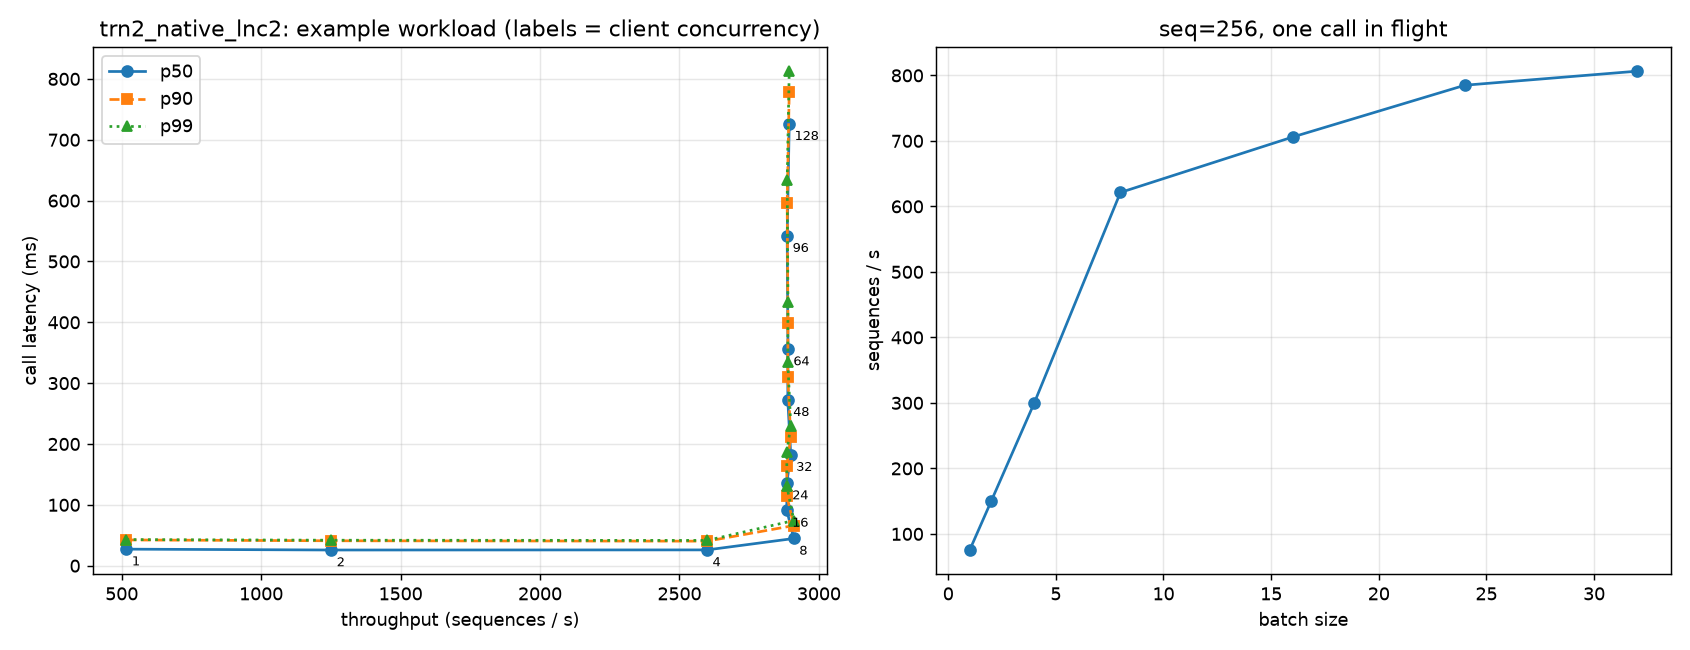

('triton-prodmix', '', 0)

In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
res = {"tag": TAG, "platform": PLATFORM, "path": PATH, "lnc": LNC, "instances": NUM_INSTANCES,
       "example_mix": {str(L): {"pct_calls": v[0], "mean_seq_per_call": v[1]} for L, v in EXAMPLE_MIX.items()},
       "target_seq_pct": {str(L): round(v, 2) for L, v in TARGET_SEQ_PCT.items()},
       "buckets": BUCKETS, "curve": CURVE, "bs_sweep_256": BS_SWEEP,
       "accuracy": acc}
os.makedirs(f"{HOME}/prodmix_results", exist_ok=True)
json.dump(res, open(f"{HOME}/prodmix_results/{TAG}.json", "w"), indent=2)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
x = [r["seq_per_s"] for r in CURVE]
for key, lbl, st in [("p50_ms", "p50", "-o"), ("p90_ms", "p90", "--s"), ("p99_ms", "p99", ":^")]:
    ax[0].plot(x, [r[key] for r in CURVE], st, label=lbl)
for r in CURVE:
    ax[0].annotate(str(r["concurrency"]), (r["seq_per_s"], r["p50_ms"]), fontsize=7,
                   xytext=(3, -9), textcoords="offset points")
ax[0].set_xlabel("throughput (sequences / s)"); ax[0].set_ylabel("call latency (ms)")
ax[0].set_title(f"{TAG}: example workload (labels = client concurrency)"); ax[0].grid(alpha=.3); ax[0].legend()
ax[1].plot([r["batch"] for r in BS_SWEEP], [r["seq_per_s"] for r in BS_SWEEP], "-o")
ax[1].set_xlabel("batch size"); ax[1].set_ylabel("sequences / s"); ax[1].grid(alpha=.3)
ax[1].set_title("seq=256, one call in flight")
plt.tight_layout()
png = f"{HOME}/prodmix_results/{TAG}.png"
plt.savefig(png, dpi=130)
print("wrote", png)
from IPython.display import Image, display
display(Image(png))
sh(["sudo", "docker", "rm", "-f", CONTAINER])